# pxts plotting demo

Interactive notebook covering all major `tsplot()` features.
Plotly charts are rendered inline; matplotlib charts use the inline backend.

**Expected CSV layout** (`examples/data/sample.csv`):
```
Date,Price_A,Price_B,Price_C,Volume
2020-01-02,100.0,200.0,50.0,1500000
2020-01-03,101.5,198.3,51.2,1320000
...
```
- First column: dates (ISO 8601 recommended)
- Price_A / Price_B / Price_C: series that share a y-axis scale
- Volume: series on a different scale (used in dual-axis examples)

## Install

Run the cell below once if `pxts` is not yet installed in this kernel.

In [1]:
# Uncomment ONE of the lines below, run once, then re-comment.
# !pip install "C:/Users/adria/Desktop/pxts"          # from PyPI
# !pip install -e "../.[plot]"     # from a local repo clone (run from examples/)

## Setup

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import pxts
from pxts import tsplot

## Load data

In [2]:
DATA_PATH = Path("data/sample.csv")

df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index)

PRICE_COLS = df.columns[:3].tolist()   # first 3 cols → left axis
# --------------------------------------------

print(f"Rows : {len(df):,}")
print(f"Range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Cols : {df.columns.tolist()}")
df.head()

Rows : 1,059
Range: 2022-01-03 → 2026-03-20
Cols : ['SPX Index', 'ES1 Index', 'NQ1 Index']


,SPX Index,ES1 Index,NQ1 Index
date,,,
2022-01-03,4796.56,5514.50,19498.88
2022-01-04,4793.54,5512.48,19250.79
2022-01-05,4700.58,5406.76,18648.45
2022-01-06,4696.05,5401.00,18639.58
2022-01-07,4677.03,5378.25,18429.04


## 1 — Minimal (all columns, Plotly)

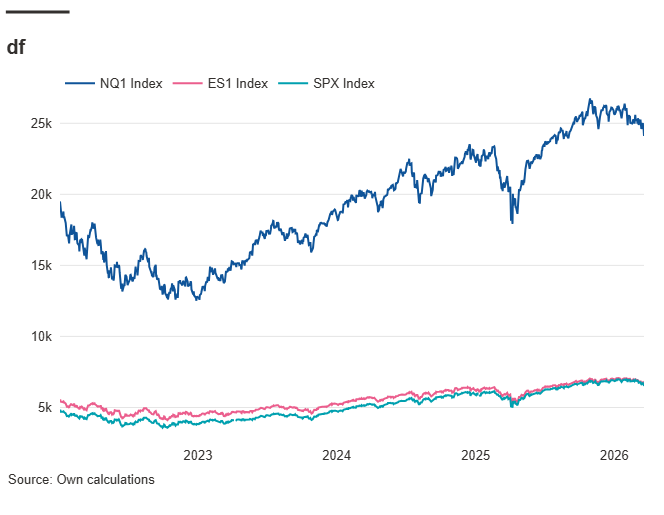

In [3]:
tsplot(df, backend="plotly")

## 2 — Title, subtitle, and source

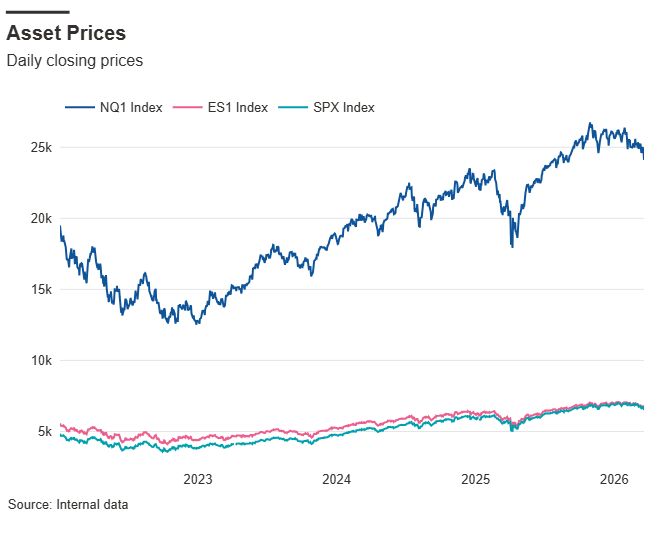

In [4]:
tsplot(
    df,
    title={"main": "Asset Prices", "sub": "Daily closing prices"},
    source=["Internal data"],
    backend="plotly",
)

## 3 — Column selection and y-axis label

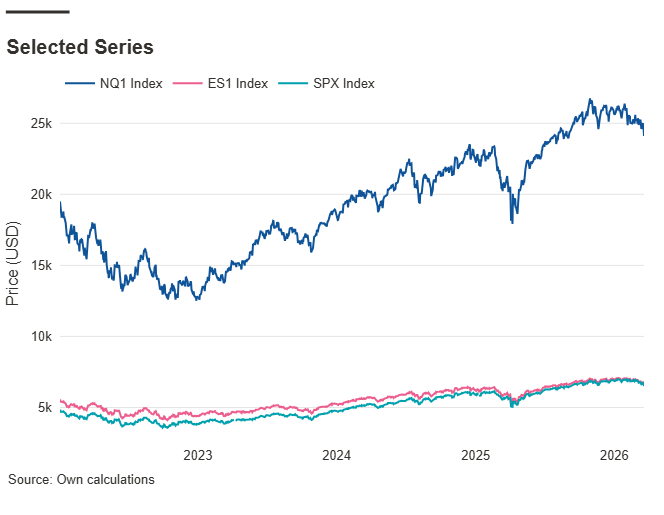

In [5]:
tsplot(
    df,
    yaxis={"cols": PRICE_COLS, "name": "Price (USD)"},
    title={"main": "Selected Series"},
    backend="plotly",
)

## 4 — FT-style end-of-line labels (no legend)

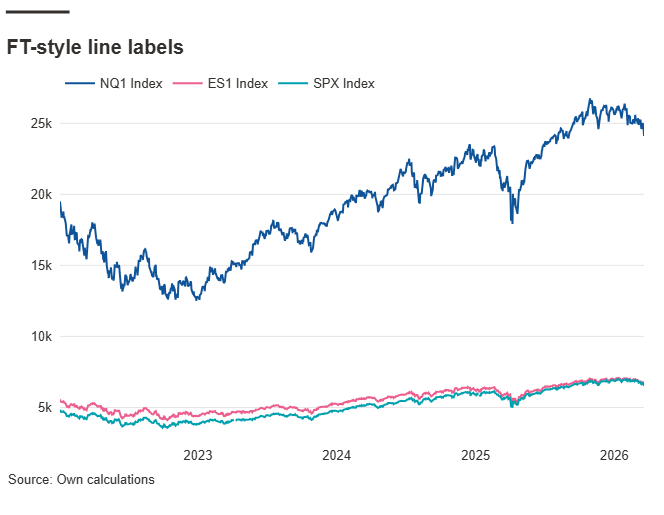

In [6]:
tsplot(
    df,
    yaxis={"cols": PRICE_COLS},
    title={"main": "FT-style line labels"},
    labels=True,
    backend="plotly",
)

## 5 — Dual axis (price left, volume right)

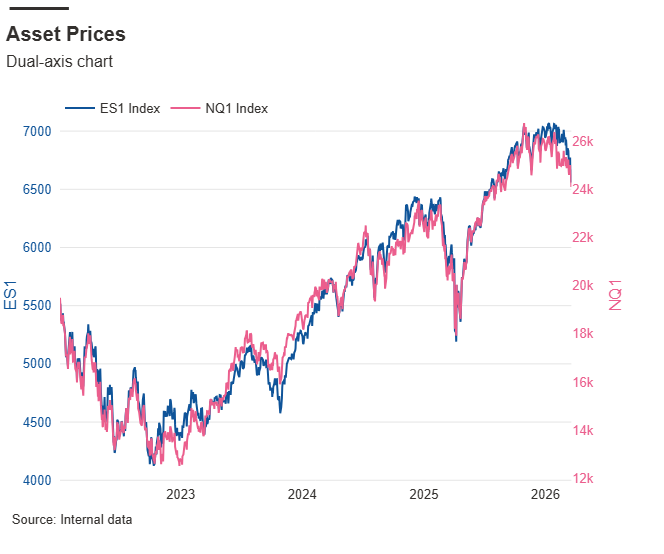

In [7]:
tsplot(
    df,
    yaxis={"cols": [PRICE_COLS[1]], "name": "ES1"},
    yaxis2={"cols": [PRICE_COLS[2]], "name": "NQ1"},
    title={"main": "Asset Prices", "sub": "Dual-axis chart"},
    #title={"main": "Asset Prices", "sub": "Daily closing prices"},
    source=["Internal data"],
    backend="plotly",
)

## 6 — Annotations (horizontal and vertical reference lines)

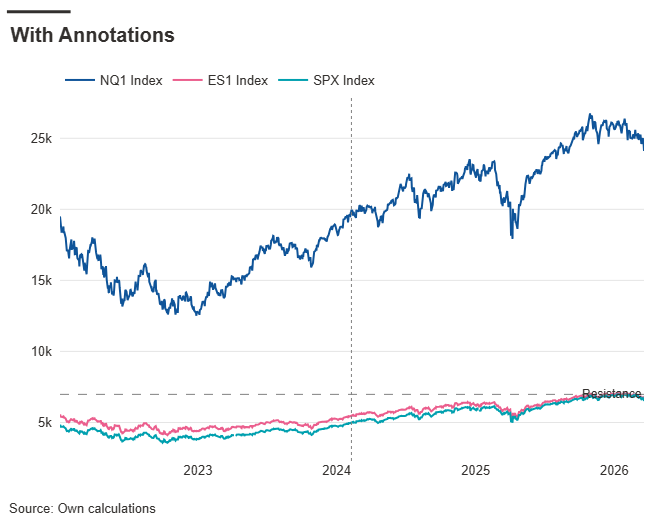

In [30]:
tsplot(
    df,
    yaxis={"cols": PRICE_COLS},
    title={"main": "With Annotations"},
    annotations={
        "hline": {"Resistance": df[PRICE_COLS[0]].max() * 1},
        "vline": [str(df.index[len(df) // 2].date())],
    },
    backend="plotly",
)

## 7 — Custom dimensions and font

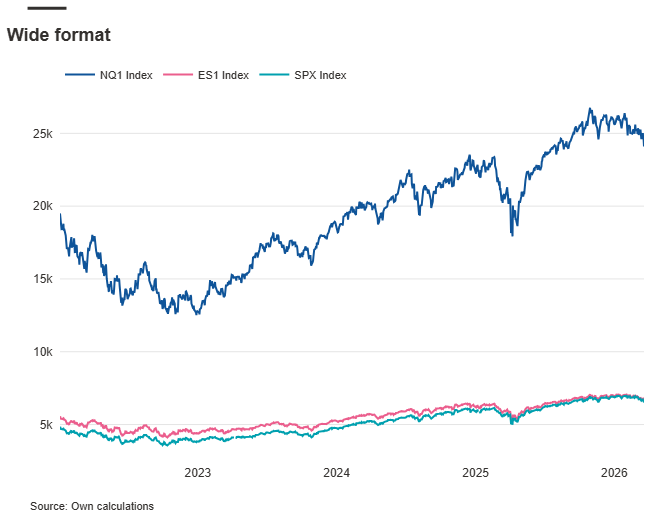

In [31]:
tsplot(
    df,
    yaxis={"cols": PRICE_COLS},
    title={"main": "Wide format"},
    dimension={"width": 900, "aspect_ratio": 2.5},
    font={"size": 12},
    backend="plotly",
)

## 8 — Matplotlib backend

Returns a `matplotlib.figure.Figure`; rendered inline via `%matplotlib inline`.

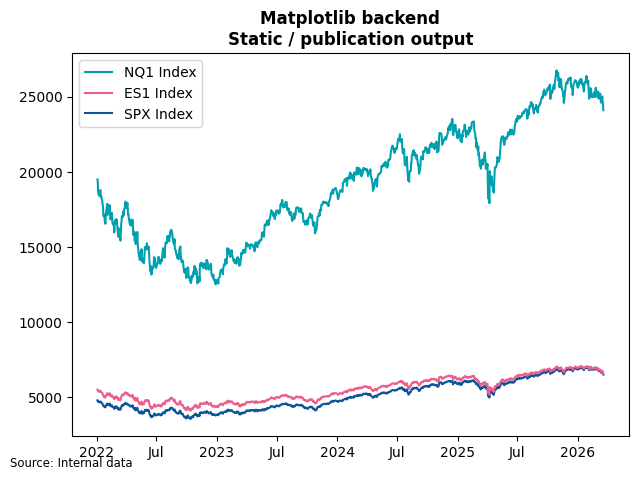

In [32]:
fig = tsplot(
    df,
    yaxis={"cols": PRICE_COLS},
    title={"main": "Matplotlib backend", "sub": "Static / publication output"},
    source=["Internal data"],
    backend="matplotlib",
)
plt.show()

## 9 — Matplotlib dual axis

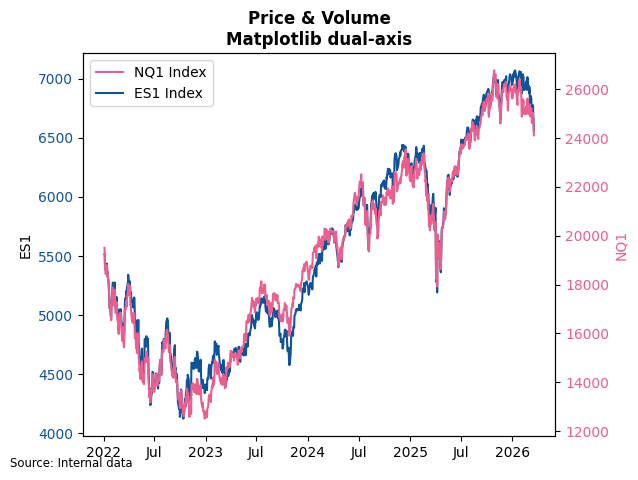

In [34]:
fig = tsplot(
    df,
    yaxis={"cols": [PRICE_COLS[1]], "name": "ES1"},
    yaxis2={"cols": [PRICE_COLS[2]], "name": "NQ1"},
    title={"main": "Price & Volume", "sub": "Matplotlib dual-axis"},
    source=["Internal data"],
    backend="matplotlib",
)
plt.show()